# 3DeeCellTracker Demo: Single mode | Use StarDist

This notebook shows how to use 3DeeCellTracker to track cells in single mode. The segmentation is basded on the trained StarDist.

The demo data and pre-trained deep neural network models can be found in the "worm1", "stardist_models" and "ffn_models" folders  downloaded from https://osf.io/pgr95/

**The basic procedures:**
- A. Import packages
- B. Segment cells by StarDist3D
- C. Load manually corrected segmentation (t=1)
- D. Track cells by FFN + PRGLS + Fine-tune.
- E. Extract activities from the tracked cells.

## A. Import packages

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
%matplotlib inline
import numpy as np

import CellTracker.trackerlite as trl
import CellTracker.stardistwrapper as sdw
import CellTracker.coord_image_transformer as cit
from CellTracker.analyses import draw_signals
from csbdeep.utils import normalize
import matplotlib.pyplot as plt
from stardist.models import StarDist2D



## B. Segment cells by StarDist2D
### Load trained StarDist3D model

### Parameters
- `model_name`: A string specifying the name of the model to reload.

### Notes:
> By default, the function looks for the model with the specified name from the stardist_models directory. However, if you have saved the model in a different location, you can specify the `basedir` parameter to load the model from that directory.
```
    model = sdw.load_stardist_model(model_name=stardist_model_name, basedir=".\FolderA\FolderB\")
```

In [7]:


model2d = StarDist2D.from_pretrained("2D_versatile_fluo")


#stardist_model_name = "stardist_worm1"

#model = sdw.load_stardist_model(model_name=stardist_model_name,   basedir="../../stardist_models")

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


### Segment the volume #1 image and save the segmentation in auto_vol1 folder

### Parameters
- `path_results`: A string specifying a directory to save the segmentation/tracking results.
- `path_raw_images`: A string specifying the file path to the raw images. The raw images could be a TIFF image sequence, or an HDF5 file with the data stored in "raw_images" key.

### Notes
> All of the time-lapse 3D images should be stored in a single directory. Each 3D image at time t should be saved as a sequence of 2D slices in TIFF format. The filename of each 2D image should contain the timing and slice number, such as "xxx_txxx_z_xxx.tif". To ensure that the program correctly loads the images for each timing, users should specify the format of the timing in the filename in the `path_raw_images` parameter. For example, "t%03d.tif" indicates that the filename should contain the letter "t" followed by a 3-digit number representing the timing, followed by any number of characters, and ending with the extension ".tif".

channel_000 raw image shape at vol 1: (1, 512, 512)
1/1 [==============================] - 0s 99ms/step
channel_001 raw image shape at vol 1: (1, 512, 512)
1/1 [==============================] - 0s 103ms/step


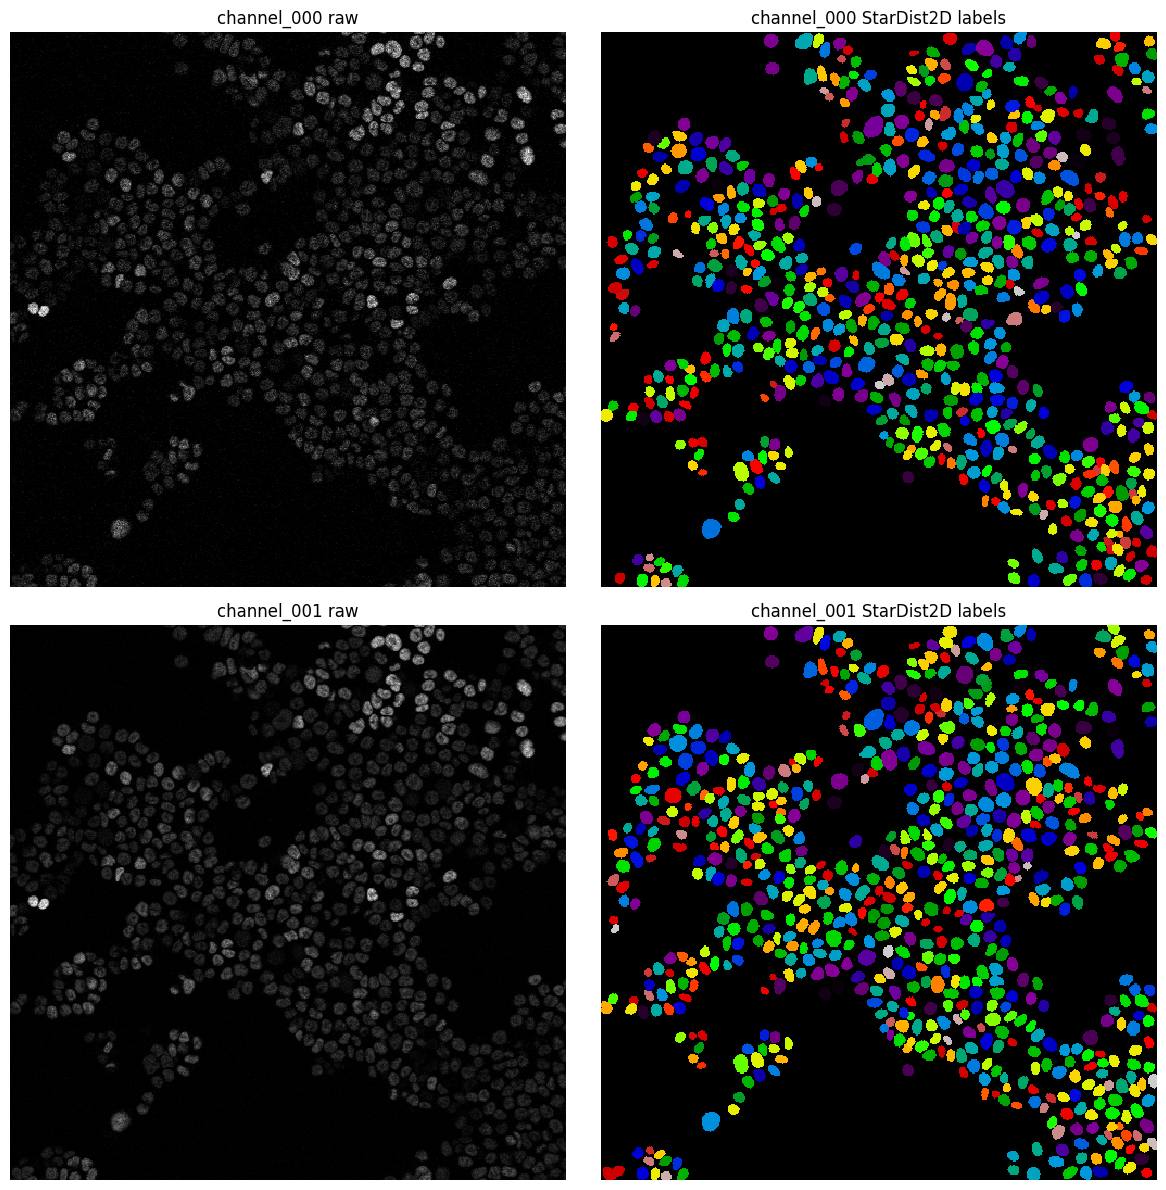

In [11]:
path_results = "G:/My Drive/GoogleColab/Deep Learnin_Farsai/datasets/results"

path_chan1 = "G:/My Drive/GoogleColab/Deep Learnin_Farsai/datasets/24h_10J/channel_000/data/*t%04d*.tif"
path_chan2 = "G:/My Drive/GoogleColab/Deep Learnin_Farsai/datasets/24h_10J/channel_001/data/*t%04d*.tif"

vol = 1

channels = {
    "channel_000": path_chan1,
    "channel_001": path_chan2,
}

results = {}

for channel_name, path_raw_images in channels.items():
    x = sdw.load_2d_slices_at_time(path_raw_images, t=vol)
    print(f"{channel_name} raw image shape at vol {vol}: {x.shape}")

    img2d = x[0]  # shape is (1, Y, X), so take the only z-slice

    labels, details = model2d.predict_instances(normalize(img2d))

    results[channel_name] = {
        "raw": img2d,
        "labels": labels,
        "details": details,
        "use_8_bit": labels.max() <= 255,
    }

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for row, channel_name in enumerate(channels.keys()):
    img2d = results[channel_name]["raw"]
    labels = results[channel_name]["labels"]

    axes[row, 0].imshow(img2d, cmap="gray")
    axes[row, 0].set_title(f"{channel_name} raw")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(labels, cmap="nipy_spectral")
    axes[row, 1].set_title(f"{channel_name} StarDist2D labels")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [13]:
from pathlib import Path
import re

import numpy as np
from csbdeep.utils import normalize
from tifffile import imwrite
from tqdm import tqdm

path_results = Path("G:/My Drive/GoogleColab/Deep Learnin_Farsai/datasets/results")
# TODO RUN SEGMENTATION ON MEAN OF BOTH CHANNEL
channels = {
    "channel_000": "G:/My Drive/GoogleColab/Deep Learnin_Farsai/datasets/24h_10J/channel_000/data/*t%04d*.tif",
    "channel_001": "G:/My Drive/GoogleColab/Deep Learnin_Farsai/datasets/24h_10J/channel_001/data/*t%04d*.tif",
}

selected_channel = "channel_000"  # change to "channel_001" if that segments better
path_raw_images = channels[selected_channel]

def get_timepoints(path_pattern):
    search_pattern = path_pattern.replace("*t%04d*", "*t*")
    files = sorted(Path().glob(search_pattern)) if not Path(search_pattern).is_absolute() else sorted(Path(search_pattern).parent.glob(Path(search_pattern).name))

    timepoints = sorted({
        int(re.search(r"t(\d+)", file.name).group(1))
        for file in files
        if re.search(r"t(\d+)", file.name)
    })

    if not timepoints:
        raise FileNotFoundError(f"No timepoints found for pattern: {search_pattern}")

    return timepoints

timepoints = get_timepoints(path_raw_images)
print(f"Found {len(timepoints)} timepoints: {timepoints[0]} to {timepoints[-1]}")

labels_dir = path_results / selected_channel / "labels"
coords_dir = path_results / selected_channel / "coords"
labels_dir.mkdir(parents=True, exist_ok=True)
coords_dir.mkdir(parents=True, exist_ok=True)

for t in tqdm(timepoints, desc=f"Segmenting {selected_channel}"):
    x = sdw.load_2d_slices_at_time(path_raw_images, t=t)
    img2d = x[0]

    labels, details = model2d.predict_instances(normalize(img2d))

    imwrite(labels_dir / f"labels_t{t:04d}.tif", labels.astype(np.uint16))
    np.save(coords_dir / f"points_t{t:04d}.npy", details["points"])

Found 16 timepoints: 1 to 16


Segmenting channel_000:   0%|                                                                   | 0/16 [00:00<?, ?it/s]

1/1 [==============================] - 0s 89ms/step


Segmenting channel_000:   6%|███▋                                                       | 1/16 [00:01<00:16,  1.09s/it]

1/1 [==============================] - 0s 97ms/step


...

Segmenting channel_000:  88%|██████████████████████████████████████████████████▊       | 14/16 [00:11<00:01,  1.11it/s]

1/1 [==============================] - 0s 80ms/step


Segmenting channel_000:  94%|██████████████████████████████████████████████████████▍   | 15/16 [00:12<00:00,  1.14it/s]

1/1 [==============================] - 0s 81ms/step


Segmenting channel_000: 100%|██████████████████████████████████████████████████████████| 16/16 [00:13<00:00,  1.18it/s]


## C. Manual correction

### Perform manual correction
- Manually correct the segmentation results saved in the "auto_vol1" folder, use software like ITK-SNAP. 
- Save the corrected segmentation as 2D slices in the TIFF format in the "manual_vol1" folder.

### Load the manually corrected segmentation

### Parameters
- `voxel_size`: A tuple of 3 numbers, indicating the size (in arbitrary units) of a voxel in the x, y, and z directions.
- `manual_seg_path`: A string specifying the file path to the manually corrected segmentation images.

## D. Tracking cells. 

### Initiate Tracker

### Parameters
- `ffn_model_name`: A string specifying the name of the ffn model to reload.

### Notes:
> By default, the function looks for the model with the specified name from the "ffn_models" directory. However, if you have saved the model in a different location, you can specify the `basedir` parameter to load the model from that directory.
```
    tracker = trl.TrackerLite(results_dir=path_results, ffn_model_name=ffn_model_name, proofed_coords_vol1=coords2image.coord_vol1, basedir=".\FolderA\FolderB\")
```    

In [14]:
from pathlib import Path
import csv
import re

import numpy as np
from scipy.optimize import linear_sum_assignment
from skimage.measure import regionprops
from tifffile import imread, imwrite
from tqdm import tqdm

path_results = Path("G:/My Drive/GoogleColab/Deep Learnin_Farsai/datasets/results")
selected_channel = "channel_000"

labels_dir = path_results / selected_channel / "labels"
tracked_dir = path_results / selected_channel / "tracked_labels"
tracked_dir.mkdir(parents=True, exist_ok=True)

tracks_csv = path_results / selected_channel / "tracks.csv"

max_displacement = 40  # pixels; tune this
max_gap = 0            # for now, only match consecutive frames

def get_t_from_name(path):
    return int(re.search(r"t(\d+)", path.name).group(1))

label_files = sorted(labels_dir.glob("labels_t*.tif"), key=get_t_from_name)

next_track_id = 1
active_tracks = {}  # track_id -> {"centroid": (y, x), "last_t": t}

rows = []

for label_file in tqdm(label_files, desc="Tracking"):
    t = get_t_from_name(label_file)
    labels = imread(label_file)

    props = regionprops(labels)
    detections = [
        {
            "label": p.label,
            "centroid": np.array(p.centroid),  # y, x
            "area": p.area,
        }
        for p in props
    ]

    tracked_labels = np.zeros_like(labels, dtype=np.uint16)

    candidate_tracks = [
        (track_id, info)
        for track_id, info in active_tracks.items()
        if t - info["last_t"] <= max_gap + 1
    ]

    assigned_detection_ids = set()
    new_active_tracks = {}

    if candidate_tracks and detections:
        prev_centroids = np.array([info["centroid"] for _, info in candidate_tracks])
        curr_centroids = np.array([d["centroid"] for d in detections])

        distances = np.linalg.norm(
            prev_centroids[:, None, :] - curr_centroids[None, :, :],
            axis=2,
        )

        row_ind, col_ind = linear_sum_assignment(distances)

        for r, c in zip(row_ind, col_ind):
            distance = distances[r, c]

            if distance > max_displacement:
                continue

            track_id = candidate_tracks[r][0]
            det = detections[c]

            assigned_detection_ids.add(c)
            new_active_tracks[track_id] = {
                "centroid": det["centroid"],
                "last_t": t,
            }

            tracked_labels[labels == det["label"]] = track_id

            rows.append({
                "t": t,
                "track_id": track_id,
                "frame_label": det["label"],
                "y": det["centroid"][0],
                "x": det["centroid"][1],
                "area": det["area"],
                "displacement": distance,
            })

    for det_id, det in enumerate(detections):
        if det_id in assigned_detection_ids:
            continue

        track_id = next_track_id
        next_track_id += 1

        new_active_tracks[track_id] = {
            "centroid": det["centroid"],
            "last_t": t,
        }

        tracked_labels[labels == det["label"]] = track_id

        rows.append({
            "t": t,
            "track_id": track_id,
            "frame_label": det["label"],
            "y": det["centroid"][0],
            "x": det["centroid"][1],
            "area": det["area"],
            "displacement": np.nan,
        })

    active_tracks = new_active_tracks

    imwrite(tracked_dir / f"tracked_labels_t{t:04d}.tif", tracked_labels)

with open(tracks_csv, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["t", "track_id", "frame_label", "y", "x", "area", "displacement"],
    )
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved tracked labels to: {tracked_dir}")
print(f"Saved track table to: {tracks_csv}")
print(f"Number of tracks: {next_track_id - 1}")

Tracking: 100%|████████████████████████████████████████████████████████████████████████| 16/16 [00:12<00:00,  1.30it/s]

Saved tracked labels to: G:\My Drive\GoogleColab\Deep Learnin_Farsai\datasets\results\channel_000\tracked_labels
Saved track table to: G:\My Drive\GoogleColab\Deep Learnin_Farsai\datasets\results\channel_000\tracks.csv
Number of tracks: 873


In [ ]:
from pathlib import Path
import csv
import re

import numpy as np
from skimage.measure import regionprops
from tifffile import imread
import matplotlib.pyplot as plt

path_results = Path("G:/My Drive/GoogleColab/Deep Learnin_Farsai/datasets/results")
selected_channel = "channel_000"

tracked_dir = path_results / selected_channel / "tracked_labels"

path_chan1 = "G:/My Drive/GoogleColab/Deep Learnin_Farsai/datasets/24h_10J/channel_000/data/*t%04d*.tif"
path_chan2 = "G:/My Drive/GoogleColab/Deep Learnin_Farsai/datasets/24h_10J/channel_001/data/*t%04d*.tif"

output_csv = path_results / selected_channel / "ratiometric_measurements.csv"

def get_t_from_name(path):
    return int(re.search(r"t(\d+)", path.name).group(1))

rows = []

label_files = sorted(tracked_dir.glob("tracked_labels_t*.tif"), key=get_t_from_name)

for label_file in label_files:
    t = get_t_from_name(label_file)

    labels = imread(label_file)

    img_ch1 = sdw.load_2d_slices_at_time(path_chan1, t=t, do_normalize=False)[0]
    img_ch2 = sdw.load_2d_slices_at_time(path_chan2, t=t, do_normalize=False)[0]

    props = regionprops(labels, intensity_image=img_ch1)

    for prop in props:
        track_id = prop.label
        mask = labels == track_id

        mean_ch1 = float(img_ch1[mask].mean())
        mean_ch2 = float(img_ch2[mask].mean())
        ratio = mean_ch2 / mean_ch1 if mean_ch1 != 0 else np.nan

        y, x = prop.centroid

        rows.append({
            "t": t,
            "track_id": track_id,
            "area": int(prop.area),
            "y": float(y),
            "x": float(x),
            "mean_ch1": mean_ch1,
            "mean_ch2": mean_ch2,
            "ratio_ch2_ch1": ratio,
        })

with open(output_csv, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "t", "track_id", "area", "y", "x",
            "mean_ch1", "mean_ch2", "ratio_ch2_ch1",
        ],
    )
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved measurements to: {output_csv}")

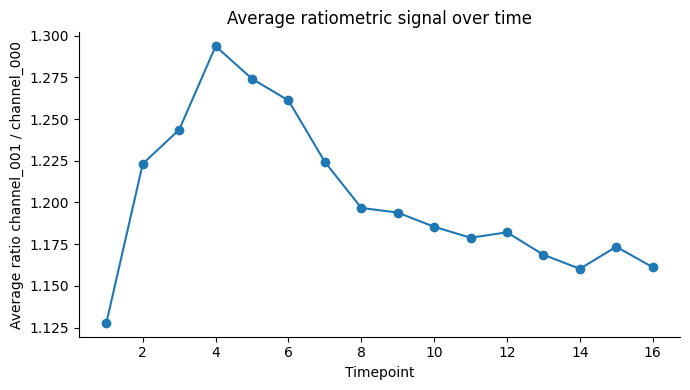

In [20]:
ratios_by_t = {}

for row in rows:
    t = row["t"]
    ratio = row["ratio_ch2_ch1"]

    if not np.isnan(ratio):
        ratios_by_t.setdefault(t, []).append(ratio)

avg_t = sorted(ratios_by_t)
avg_ratio = [np.mean(ratios_by_t[t]) for t in avg_t]

plt.figure(figsize=(7, 4))
plt.plot(avg_t, avg_ratio, marker="o")
plt.xlabel("Timepoint")
plt.ylabel("Average ratio channel_001 / channel_000")
plt.title("Average ratiometric signal over time")
plt.tight_layout()
plt.show()

### Test FFN matching

### Parameters
- `t1`: An integer specifying the volume number of the first segmentation
- `t2`: An integer specifying the volume number of the second segmentation

### Notes:
>  The program will match the segmented cell centers points (saved in the "seg" folder) between volumes t1 and t2.

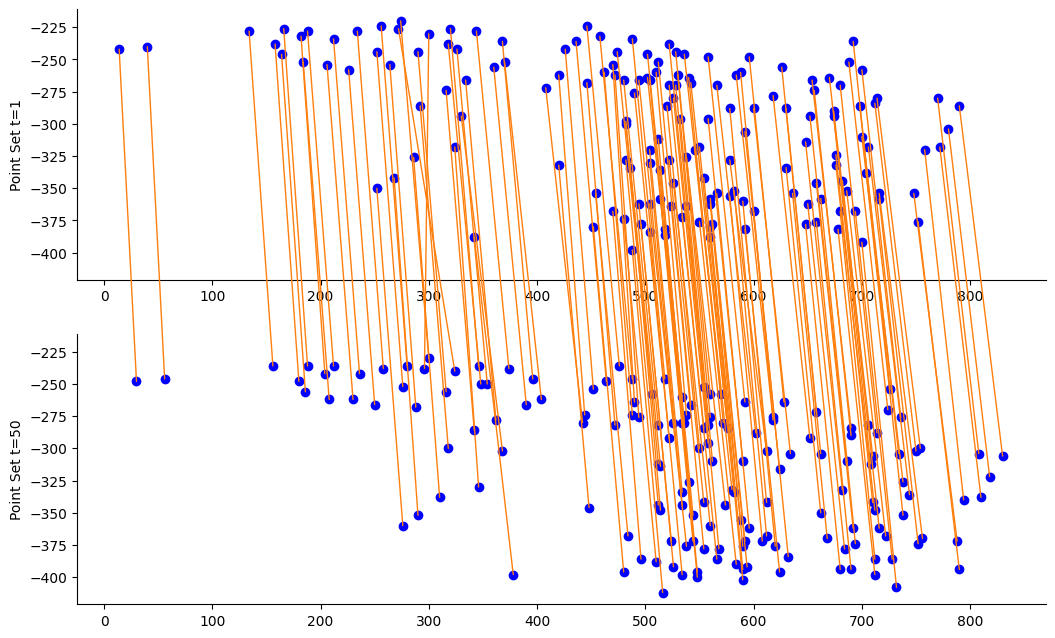

In [8]:
t1 = 1
t2 = 50

tracker.match_by_ffn(t1=t1, t2=t2)

### Test FFN + PR-GLS tracking

### Parameters
- `beta`: A numeric value (integer or float). A larger value will result in a larger window for estimating cell movement based on neighboring cells.
- `lambda_`: A numeric value (integer or float). A larger value will result in more similar movements across different cells.

### Notes:
> The program will estimate the new positions at time point `t2` for all cells segmented at time point `t1`. The FFN matching will be improved by PR-GLS to generate a more coherent estimation of cell movements.

> The default values of `beta` and `lambda_` are (3, 3), which are suitable for most cases. However, users can try different values to further improve the tracking.

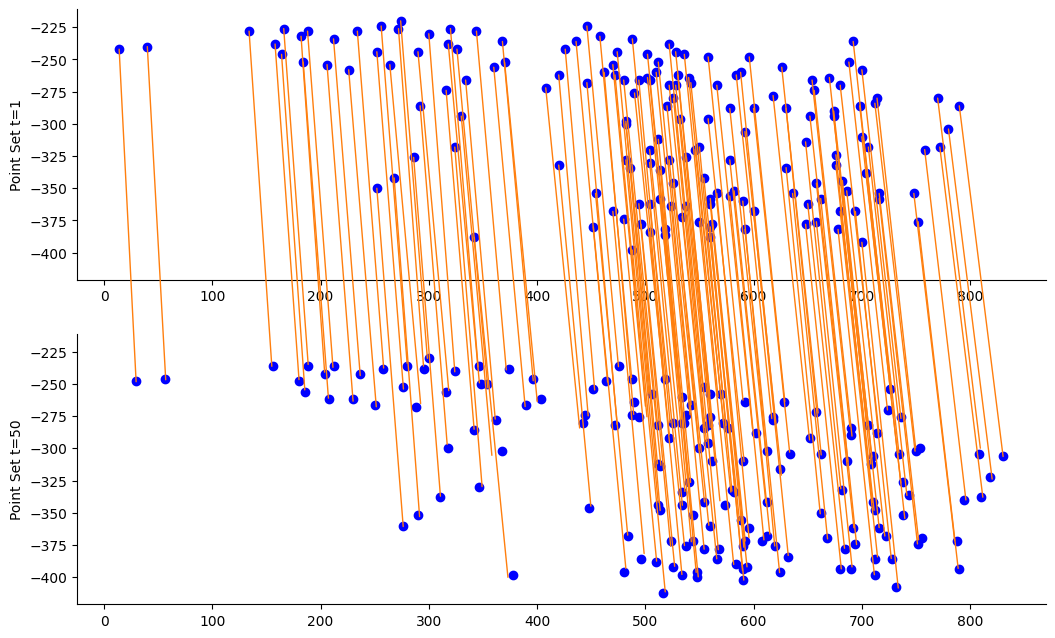

In [9]:
beta = 3
lambda_= 3

tracked_positions_t2 = tracker.predict_cell_positions(t1=1, t2=50, beta=beta, lambda_=lambda_, draw_fig=True)

### Track cells in following volumes in single mode

### Parameters
- `t_start`: An integer specifying the volume number of the first raw image. Usually, this value is set to 1, so that the program will load coordinates in volume 2, 3, 4, and so on for tracking. If `t_start` is not 1, then the subsequent volume numbers will be `t_start + 1`, `t_start + 2`, and so on.
- `t_end`: An integer specifying the volume number of the last raw image that should be tracked.
- `skipped_volumes`: A list of integers specifying the volumes that should be skipped during tracking. An empty list [] means no volume will be skipped.

### Notes:
> All tracking results will be automatically saved in the "track_results" folder, including:
> 1. The coordinates of tracked cells (in the same units as the `voxel_size`) - Folder "coords_real"
> 2. Figures showing the tracking in each volume - Folder "figure"
> 3. Images of the tracked labels in each volume - Folder "labels"
> 4. Merged images of the raw image and the tracked labels in each volume, projected on the x-y plane - Folder "merged_labels"
> 5. Merged images of the raw image and the tracked labels in each volume, projected on the x-z plane - Folder "merged_labels_xz"

In [10]:
t_start = 1
t_end = 50
skipped_volumes = []

ensemble = False
t1 = t_start
confirmed_coord = coords2image.coord_vol1
grid = model.config.grid
for t in range(t_start+1, t_end+1):
    print(f"t={t}...", end="\r")
    if t in skipped_volumes:
        print(f"skip t={t}")
        continue
    coord_prgls = tracker.predict_cell_positions(t1=t1, t2=t, confirmed_coord_t1=confirmed_coord, beta=beta, lambda_=lambda_, draw_fig=False)
    confirmed_coord, corrected_labels_image = coords2image.accurate_correction(t, grid, coord_prgls, ensemble=ensemble)
    coords2image.save_tracking_results(confirmed_coord, corrected_labels_image, tracker, t1=t1, t2=t, images_path=path_raw_images)
    t1 = t

## E. Extract activities from tracked cells

### Extract activities

### Parameters
- `raw_path`: A string specifying the file path to the raw image to extract the activities. The image data should be in TIFF format.

### Notes
> This Code Block extracts activities from 3D time-lapse images, based on tracking results.

In [12]:
raw_path = "./worm1/data/*t%03d*.tif"

activities = tracker.activities(raw_path=raw_path)

### Draw a figure to show the activities

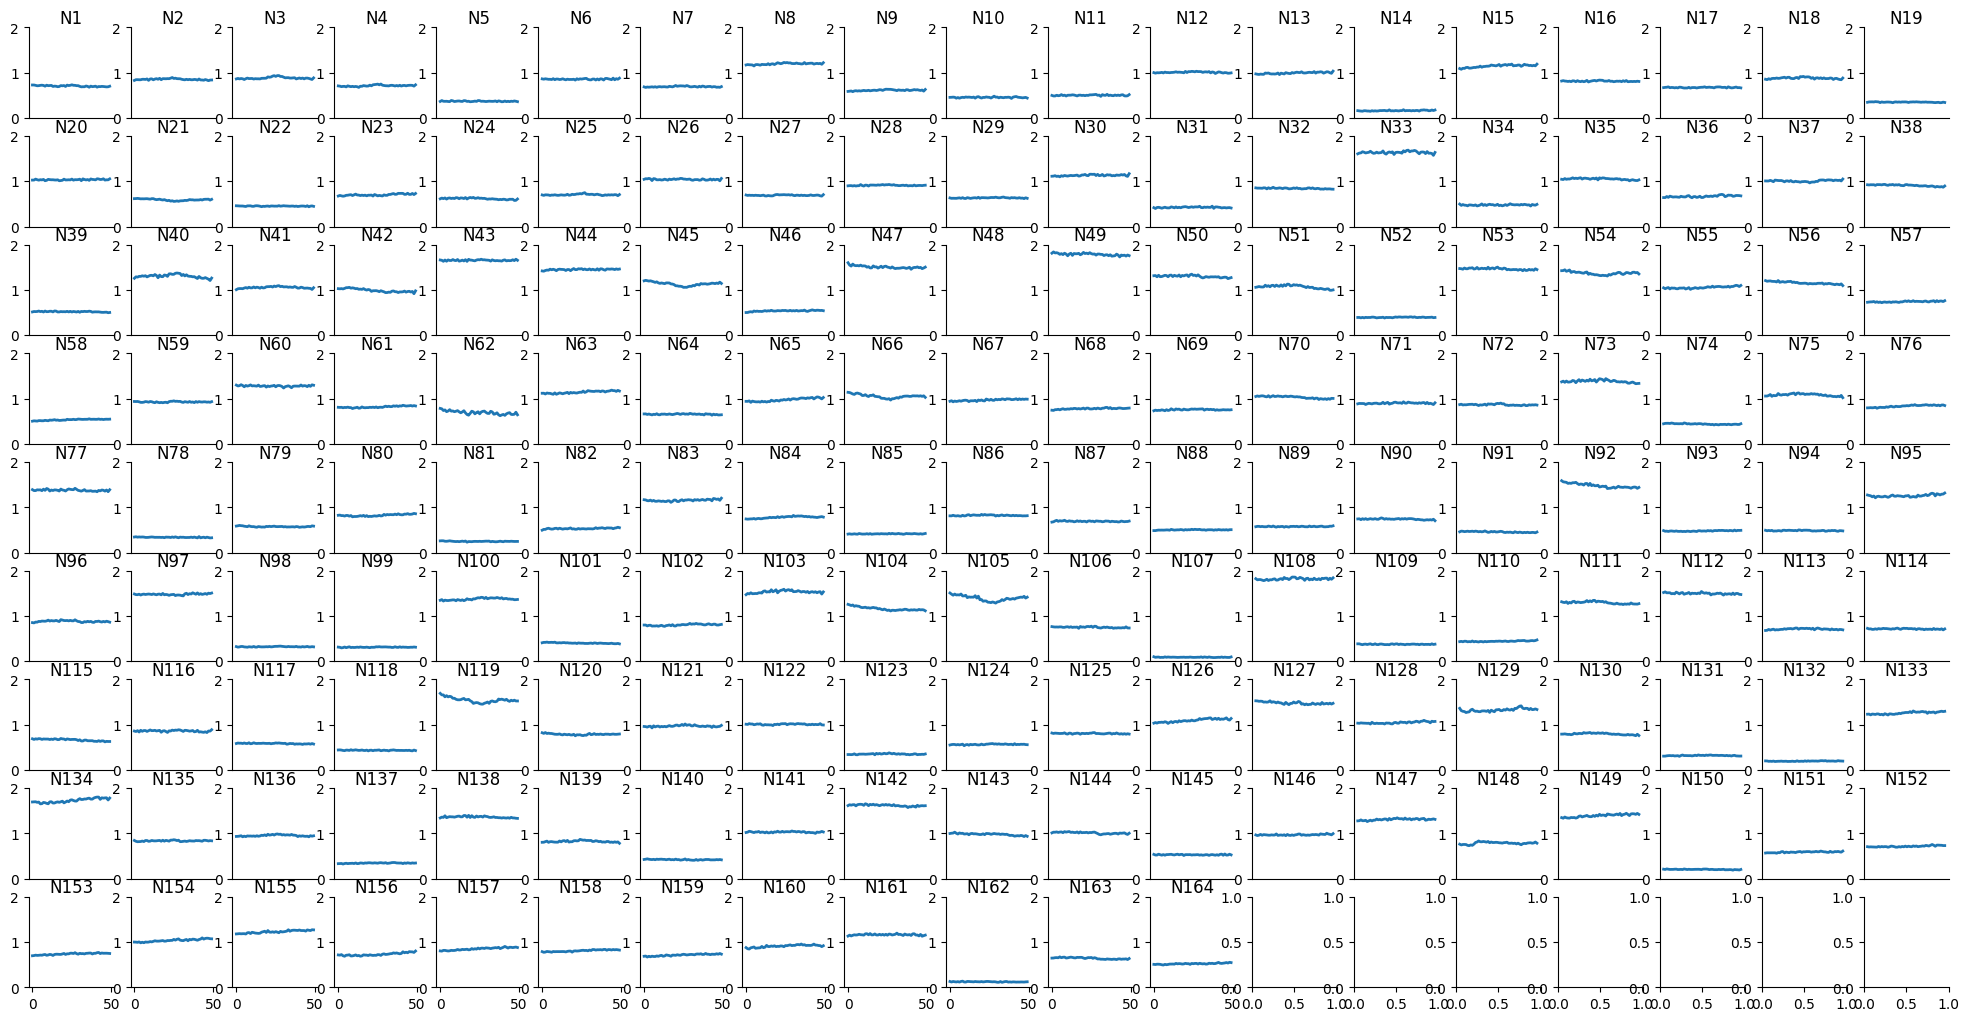

In [13]:
draw_signals(activities, ylim_lower=0, ylim_upper=2, figsize=(20, 10))

### Export the activities as csv file

### Parameters
- `csv_filename`: The filename of the csv file to save the extracted activities

In [14]:
csv_filename = "activities_txcell.csv"

csv_filename = os.path.join(path_results, csv_filename)
timings = np.arange(1, activities.shape[0]+1).reshape(-1, 1)
activities_with_timings = np.concatenate((timings, activities), axis=1)
headers = ['timing'] + ['cell' + str(i) for i in range(1, activities.shape[1]+1)]
np.savetxt(csv_filename, activities_with_timings, delimiter=',', fmt='%.3f', header=','.join(headers), comments='')
print(f"The cell activities have been saved in {csv_filename}")

The cell activities have been saved in ./worm1/activities_txcell.csv
